In [1]:
import numpy as np
import pandas as pd

# 1.数据集成
数据集成是把不同来源、格式、特点和性质的数据在逻辑或物理上有机的集中，从而为企业提供全面的数据共享，即将多个数据源合并存放在一个一致的数据存储中的过程。

## 1.1数据集成需要解决的问题
数据来源于各种渠道，有的是连续的数据或是离散数据，有的是定性数据或是定量数据。
在进行数据的集成过程中，一般需要考虑以下问题：实体识别、冗余属性识别和数据不一致等问题。

（1）冗余属性  
数据集成往往导致数据冗余，常见形式如下。  
①同一属性多次出现，比如两个数据源都记录每天的最高温度和最低温度，当数据集成时，就出现了两次。  
②同一属性命名不一致导致重复。

（2）实体识别  
①同名异义：数据源A和数据源B的某个数据特征的名称一样，但是表示的内容不一样。数据源A和数据源B中的属性ID分别描述的是菜品编号和订单编号，即描述的是不同的实体。  
②异名同义：数据源A和数据源B的某个特征名称不一样，但是表达的内容一样。例如，数据源A中的sales_dt和数据源B中的sales_date都是描述销售日期的，即A.sales_dt=B.sales_date。  
③单位不统一：不同的数据源记录的单位不一样，比如统计身高，一个数据源以米为单位，一个以尺为单位，描述同一个实体分别用的是国际单位和中国传统的计量单位。

## 1.2数据集成函数与方法

（1）数据的**连接与合并**是指对两个或多个DataFrame对象、Series对象进行连接或合并操作。  
（2）**数据的连接或合并可以上下（拼接行）或者左右（连接列）**。需要重点理解的是：**上下拼接一般是按照列的名字进行拼接；而左右连接操作方式比较多，比如可以按照两个DataFrame对象的行索引进行连接、合并；也可以指定某一个列（key）进行连接**。<br>
（3）常用的方法主要有：  

【堆叠合并】 ：简单粗暴的拼接**行拼接，看列名；列拼接，看行索引。**     
1）**pd.concat()**：函数；上下或左右**“拼接”**。<br>
   
【主键合并】 ：基于字段内涵的合并    
1）**df.merge()**：实现对两个（**只能是两个**）DataFrame对象或Series对象进行合并；pd.merge()函数和df.merge()方法是按照**指定列**的值（参数为：**on或left_on，right_on**）进行**业务逻辑上的合并**；也可以按照**行索引**进行合并。而pd.concat()函数都仅仅是按照标签（行索引或列名）进行简单拼接。  
2）df.join()：df.join()方法可以以行索引为key进行两个DataFrame对象的合并。可以理解成是**df.merge()的一种特例**。<br> 
   
【重叠合并】：自定义规则的合并    
1）df.combine()：combine()方法可以自定义合并的规则。当需要合并两个相似的数据集，且两个数据集里的数据各有一部分是目标数据时，很适合使用combine()方法。相当于不是简单的连接、合并，而是基于自定义函数规则进行合并，灵活度更高。

# 2.堆叠合并
## 2.1pd.concat()函数

（1）pd.concat()函数的作用是将**两个或多个DataFrame对象或Series对象**在**指定的坐标轴（axis）**上进行**连接**。<br>
（2）在指定坐标轴上进行连接是指按照**相同的行索引（axis=0）或者列索引（axis=1）**进行**拼接**，即拼接的**依据是行索引或列索引的标签**。<br>
（3）注意：是**pd.concat()函数**，而不是df.concat()方法。  
（4）重点参数：axis、join、ignore_index等。  
1）axis=0或axis=1，默认是：axis=0。  
2）join：inner**（交集）**或者outer**（并集）**，默认是：outer；这里的交集和并集是**指行索引或列索引的交集或并集**。<br>
3）ignore_index：忽略原来多个对象的所有行索引或列索引，程序重新生成新的行**位置索引**或列**位置索引**。

In [2]:
df1 = pd.DataFrame({'A': list('AAA'), 'B': list('BBB'), 'C': list('CCC')})
df1

,A,B,C
0,A,B,C
1,A,B,C
2,A,B,C


In [3]:
df2 = pd.DataFrame({'B': list('BBBB'),'D': list('DDDD'),'E': list('EEEE'),'C': list('CCCC')})
df2

,B,D,E,C
0,B,D,E,C
1,B,D,E,C
2,B,D,E,C
3,B,D,E,C


In [4]:
# 上下合并df1和df2取并集
pd.concat([df1,df2],axis= 0,join='outer')

,A,B,C,D,E
0,A,B,C,NaN,NaN
1,A,B,C,NaN,NaN
2,A,B,C,NaN,NaN
0,NaN,B,C,D,E
1,NaN,B,C,D,E
2,NaN,B,C,D,E
3,NaN,B,C,D,E


In [5]:
# 上下合并df1和df2取交集，并重置索引
pd.concat([df1,df2],axis=0,join= 'inner',ignore_index= True )

,B,C
0,B,C
1,B,C
2,B,C
3,B,C
4,B,C
5,B,C
6,B,C


In [6]:
# 左右合并df1和df2取并集
pd.concat([df1,df2],axis= 1,join='outer')

,A,B,C,B,D,E,C
0,A,B,C,B,D,E,C
1,A,B,C,B,D,E,C
2,A,B,C,B,D,E,C
3,NaN,NaN,NaN,B,D,E,C


In [7]:
# 左右合并df1和df2取交集
pd.concat([df1,df2],axis= 1,join= 'inner')

,A,B,C,B,D,E,C
0,A,B,C,B,D,E,C
1,A,B,C,B,D,E,C
2,A,B,C,B,D,E,C


In [8]:
df3 = pd.DataFrame({'A': list('1111'), 'B': list('2222'), 'D': list('3333'), 'E': list('4444')})
df3

,A,B,D,E
0,1,2,3,4
1,1,2,3,4
2,1,2,3,4
3,1,2,3,4


In [9]:
# 合并三个数据，重置索引
pd. concat([df1,df2,df3],ignore_index= True)

,A,B,C,D,E
0,A,B,C,NaN,NaN
1,A,B,C,NaN,NaN
2,A,B,C,NaN,NaN
3,NaN,B,C,D,E
4,NaN,B,C,D,E
5,NaN,B,C,D,E
6,NaN,B,C,D,E
7,1,2,NaN,3,4
8,1,2,NaN,3,4
9,1,2,NaN,3,4


# 3.主键合并
## 3.1 pd.merge()函数或df.merge()方法

（1）pd.merge()函数和df.merge()方法是等效的，可以实现对**（只能是两个）**两个DataFrame对象或Series对象进行合并。  
（2）pd.merge()函数和df.merge()方法是按照**指定列的值（参数为：on或left_on，right_on）进行业务逻辑上的合并**；也可以按照行索引进行合并。而pd.concat()函数和df.append()方法都仅仅是按照标签（行索引或列名）进行匹配拼接。  
（3）主要参数如下：  
1）left：左边要合并的DataFrame对象。  
2）right：右边要合并的DataFrame对象或named Series对象。  
3）**how**：取值为**'left', 'right', 'outer', 'inner', 'cross'**,**默认值是'inner'**。<br>
3.1）**left：左连接。**仅以左边的DataFrame对象为标准进行连接，相当于SQL的“左外连接”。    
3.2）**right：右连接。**仅以右边的DataFrame对象为标准进行连接，相当于SQL的“右外连接”。  
3.3）**outer：外连接。**以两个DataFrame对象的键的**并集**为标准进行连接，相当于SQL的“全连接”。  
3.4）**inner：内连接。**以两个DataFrame对象的键的**交集**为标准进行连接，相当于SQL的“内连接”。  
3.5）cross：笛卡尔积（cartesian product）连接。也称为交叉连接（Cross Join），是指将左表的每一行与右表的每一行进行组合，生成所有可能的行组合。    
4）**on**：数据合并参考的基准列名（**外键**）。**前提：两个DataFrame对象中都必须含有相同的此列名**。此外，on可以是列表类型，即多个列名构成的合并参考基准（**复合外键**）。<br>
5）left_on和right_on：当两个DataFrame对象中合并参考的基准列名不一样时，如一个表叫做商品ID，一个表叫做商品编号，则无法直接使用on，只能使用left_on和right_on分别指定。  
6）left_index和right_index：取值为Boolean类型，默认为False；即是否使用**行索引**为基准key进行连接。注意：**这两对参数与on或者left_on、right_on只能同时出现一种，即要么按照索引为key进行连接，要么按照列名（如on）进行连接**。此外，当left_index和right_index均为True时，其作用**相当于pd.concat([df1,df2],axis=1)**。

In [10]:
# 情况1，含有相同字段
# 获奖明细表
df1 = pd.DataFrame({
    '学号': ['001', '003', '005', '006', '007', '008'],
    '姓名': ['熊大', '熊三', '熊五', '熊六', '熊七', '熊八'],
    '获奖等级': ['一等奖', '三等奖', '三等奖', '二等奖', '一等奖', '二等奖']
})
df1

,学号,姓名,获奖等级
0,001,熊大,一等奖
1,003,熊三,三等奖
2,005,熊五,三等奖
3,006,熊六,二等奖
4,007,熊七,一等奖
5,008,熊八,二等奖


In [11]:
# 学生信息表
df2 = pd.DataFrame({
    '学号': ['001', '002', '003', '004', '005', '006'],
    '姓名': ['熊大', '熊二', '熊三', '熊四', '熊五', '熊六'],
    '性别': ['男', '女', '男', '男', '女', '女'],
    '专业': ['大数据技术', '软件工程', '软件工程', '物联网', '大数据技术', '人工智能'],
    '年级': ['2018', '2020', '2019', '2020', '2018', '2018']
})
df2

,学号,姓名,性别,专业,年级
0,001,熊大,男,大数据技术,2018
1,002,熊二,女,软件工程,2020
2,003,熊三,男,软件工程,2019
3,004,熊四,男,物联网,2020
4,005,熊五,女,大数据技术,2018
5,006,熊六,女,人工智能,2018


In [12]:
# 根据学号进行内连接
pd.merge(df1,df2,on='学号',how= 'inner')

,学号,姓名_x,获奖等级,姓名_y,性别,专业,年级
0,001,熊大,一等奖,熊大,男,大数据技术,2018
1,003,熊三,三等奖,熊三,男,软件工程,2019
2,005,熊五,三等奖,熊五,女,大数据技术,2018
3,006,熊六,二等奖,熊六,女,人工智能,2018


In [13]:
# 根据学号和姓名两列进行外连接
pd.merge(df1,df2,on= ['学号','姓名'],how='outer')

,学号,姓名,获奖等级,性别,专业,年级
0,001,熊大,一等奖,男,大数据技术,2018
1,002,熊二,NaN,女,软件工程,2020
2,003,熊三,三等奖,男,软件工程,2019
3,004,熊四,NaN,男,物联网,2020
4,005,熊五,三等奖,女,大数据技术,2018
5,006,熊六,二等奖,女,人工智能,2018
6,007,熊七,一等奖,NaN,NaN,NaN
7,008,熊八,二等奖,NaN,NaN,NaN


In [14]:
# 根据学号列进行左连接
pd.merge(df1,df2,on= '学号',how= 'left')

,学号,姓名_x,获奖等级,姓名_y,性别,专业,年级
0,001,熊大,一等奖,熊大,男,大数据技术,2018
1,003,熊三,三等奖,熊三,男,软件工程,2019
2,005,熊五,三等奖,熊五,女,大数据技术,2018
3,006,熊六,二等奖,熊六,女,人工智能,2018
4,007,熊七,一等奖,NaN,NaN,NaN,NaN
5,008,熊八,二等奖,NaN,NaN,NaN,NaN


In [15]:
# 根据学号和姓名两列进行右连接
pd.merge(df1,df2,on= ['学号','姓名'],how= 'right')

,学号,姓名,获奖等级,性别,专业,年级
0,001,熊大,一等奖,男,大数据技术,2018
1,002,熊二,NaN,女,软件工程,2020
2,003,熊三,三等奖,男,软件工程,2019
3,004,熊四,NaN,男,物联网,2020
4,005,熊五,三等奖,女,大数据技术,2018
5,006,熊六,二等奖,女,人工智能,2018


In [16]:
# 情况2，字段名不同但含义相同
df3 = pd.DataFrame({
    '商品ID': ['A001', 'A002', 'A003', 'A004'],
    '商品名称': ['手机', '笔记本', '平板', '耳机'],
    '价格': [2999, 5999, 3999, 599]})
df3

,商品ID,商品名称,价格
0,A001,手机,2999
1,A002,笔记本,5999
2,A003,平板,3999
3,A004,耳机,599


In [17]:
df4 = pd.DataFrame({
    '商品编号': ['A001', 'A002', 'A003', 'A005'],
    '库存数量': [100, 50, 80, 200],
    '供应商': ['供应商A', '供应商B', '供应商A', '供应商C']})
df4

,商品编号,库存数量,供应商
0,A001,100,供应商A
1,A002,50,供应商B
2,A003,80,供应商A
3,A005,200,供应商C


In [18]:
# 根据商品ID和商品编号两列进行外连接
df = pd.merge(df3,df4,left_on= '商品ID',right_on= '商品编号',how= 'outer')
df

,商品ID,商品名称,价格,商品编号,库存数量,供应商
0,A001,手机,2999.0,A001,100.0,供应商A
1,A002,笔记本,5999.0,A002,50.0,供应商B
2,A003,平板,3999.0,A003,80.0,供应商A
3,A004,耳机,599.0,NaN,NaN,NaN
4,NaN,NaN,NaN,A005,200.0,供应商C


In [20]:
# 当一个数据出现缺失时，使用另外一个数据进行填充，方法combine_first()
# 保留商品ID或商品编号中的一列，使两者的值进行填充
df['商品ID'] = df['商品ID'].combine_first(df['商品编号'])
df.drop(columns= '商品编号',inplace= True )
df

,商品ID,商品名称,价格,库存数量,供应商
0,A001,手机,2999.0,100.0,供应商A
1,A002,笔记本,5999.0,50.0,供应商B
2,A003,平板,3999.0,80.0,供应商A
3,A004,耳机,599.0,NaN,NaN
4,A005,NaN,NaN,200.0,供应商C


In [21]:
# 情况3，索引有相同含义
df5 = pd.DataFrame({
    '商品名称': ['手机', '笔记本', '平板', '耳机'],
    '价格': [2999, 5999, 3999, 599]
}, index=['A001', 'A002', 'A003', 'A004'])
df5

,商品名称,价格
A001,手机,2999
A002,笔记本,5999
A003,平板,3999
A004,耳机,599


In [22]:
df6 = pd.DataFrame({
    '库存数量': [100, 50, 80, 200],
    '供应商': ['供应商A', '供应商B', '供应商A', '供应商C']
}, index=['A001', 'A002', 'A003', 'A005'])
df6

,库存数量,供应商
A001,100,供应商A
A002,50,供应商B
A003,80,供应商A
A005,200,供应商C


In [23]:
# 根据索引进行外连接
pd. merge(df5,df6,left_index= True ,right_index= True ,how= 'outer')      

,商品名称,价格,库存数量,供应商
A001,手机,2999.0,100.0,供应商A
A002,笔记本,5999.0,50.0,供应商B
A003,平板,3999.0,80.0,供应商A
A004,耳机,599.0,NaN,NaN
A005,NaN,NaN,200.0,供应商C


情况4，笛卡尔积连接  
适用场景  
（1）生成所有可能的组合  
（2）参数网格搜索  
（3）时间序列扩展  
（4）测试用例生成

In [24]:
# （1）电商应用：生成所有商品属性组合
colors = pd.DataFrame({'颜色': ['红色', '蓝色', '黑色']})
sizes = pd.DataFrame({'尺寸': ['S', 'M', 'L']})
materials = pd.DataFrame({'材质': ['棉', '涤纶', '丝绸']})

# 生成所有可能的SKU组合
all_combinations = pd.merge(
    pd.merge(colors, sizes, how='cross'),
    materials, how='cross'
)
all_combinations

,颜色,尺寸,材质
0,红色,S,棉
1,红色,S,涤纶
2,红色,S,丝绸
3,红色,M,棉
4,红色,M,涤纶
5,红色,M,丝绸
6,红色,L,棉
7,红色,L,涤纶
8,红色,L,丝绸
9,蓝色,S,棉


In [25]:
# （2）机器学习：生成超参数网格，作用：使用网格搜索系统化参数调优。
learning_rates = pd.DataFrame({'学习率': [0.1, 0.01, 0.001]})
batch_sizes = pd.DataFrame({'批量大小': [16, 32, 64]})
optimizers = pd.DataFrame({'优化器': ['Adam', 'SGD', 'RMSprop']})

# 生成所有超参数组合
param_grid = pd.merge(
    pd.merge(learning_rates, batch_sizes, how='cross'),
    optimizers, how='cross'
)
param_grid

,学习率,批量大小,优化器
0,0.100,16,Adam
1,0.100,16,SGD
2,0.100,16,RMSprop
3,0.100,32,Adam
4,0.100,32,SGD
5,0.100,32,RMSprop
6,0.100,64,Adam
7,0.100,64,SGD
8,0.100,64,RMSprop
9,0.010,16,Adam


In [26]:
# （3）业务分析：为所有日期和产品生成记录
dates = pd.DataFrame({
    '日期': pd.date_range('2024-01-01', periods=3)
})
products = pd.DataFrame({
    '产品': ['A', 'B', 'C']
})

# 生成完整的日期-产品矩阵
date_product_matrix = pd.merge(dates, products, how='cross')
date_product_matrix

,日期,产品
0,2024-01-01,A
1,2024-01-01,B
2,2024-01-01,C
3,2024-01-02,A
4,2024-01-02,B
5,2024-01-02,C
6,2024-01-03,A
7,2024-01-03,B
8,2024-01-03,C


In [27]:
# （4）软件测试：生成浏览器兼容性测试矩阵
browsers = pd.DataFrame({'浏览器': ['Chrome', 'Firefox', 'Safari', 'Edge']})
oses = pd.DataFrame({'操作系统': ['Windows', 'macOS', 'Linux']})
resolutions = pd.DataFrame({'分辨率': ['1920x1080', '1366x768', 'mobile']})

# 生成完整的测试矩阵
test_matrix = pd.merge(
    pd.merge(browsers, oses, how='cross'),
    resolutions, how='cross'
)
test_matrix

,浏览器,操作系统,分辨率
0,Chrome,Windows,1920x1080
1,Chrome,Windows,1366x768
2,Chrome,Windows,mobile
3,Chrome,macOS,1920x1080
4,Chrome,macOS,1366x768
5,Chrome,macOS,mobile
6,Chrome,Linux,1920x1080
7,Chrome,Linux,1366x768
8,Chrome,Linux,mobile
9,Firefox,Windows,1920x1080


## 3.2 df.join()方法

（1）df.join()方法可以以行索引为key进行两个DataFrame对象的合并。  
（2）主要参数包括：  
1）on：用于连接的列名或索引级别名称。如果指定，则使用该列而不是索引进行连接。注意，这会将指定的列作为连接键，但连接后该列会成为索引，除非使用 lsuffix和 rsuffix来避免重复列名。   
2）how：{‘left’, ‘right’, ‘outer’, ‘inner’}, default ‘left’。  
3）lsuffix：左DataFrame中重复列的后缀。   
4）rsuffix：右DataFrame中重复列的后缀。     
5）sort:如果为 True，则根据连接键对结果进行排序。

In [28]:
# 获奖明细表
df1 = pd.DataFrame({
    '学号': ['001', '003', '005', '006', '007', '008'],
    '姓名': ['熊大', '熊三', '熊五', '熊六', '熊七', '熊八'],
    '获奖等级': ['一等奖', '三等奖', '三等奖', '二等奖', '一等奖', '二等奖']
})
df1

,学号,姓名,获奖等级
0,001,熊大,一等奖
1,003,熊三,三等奖
2,005,熊五,三等奖
3,006,熊六,二等奖
4,007,熊七,一等奖
5,008,熊八,二等奖


In [29]:
# 学生信息表
df2 = pd.DataFrame({
    '学号': ['001', '002', '003', '004', '005', '006'],
    '姓名': ['熊大', '熊二', '熊三', '熊四', '熊五', '熊六'],
    '性别': ['男', '女', '男', '男', '女', '女'],
    '专业': ['大数据技术', '软件工程', '软件工程', '物联网', '大数据技术', '人工智能'],
    '年级': ['2018', '2020', '2019', '2020', '2018', '2018']
})
df2

,学号,姓名,性别,专业,年级
0,001,熊大,男,大数据技术,2018
1,002,熊二,女,软件工程,2020
2,003,熊三,男,软件工程,2019
3,004,熊四,男,物联网,2020
4,005,熊五,女,大数据技术,2018
5,006,熊六,女,人工智能,2018


In [30]:
# df1和df2根据索引进行左连接，设置左边后缀_x,后边后缀_y
df1.join(df2,lsuffix= '_x',rsuffix= '_y')

,学号_x,姓名_x,获奖等级,学号_y,姓名_y,性别,专业,年级
0,001,熊大,一等奖,001,熊大,男,大数据技术,2018
1,003,熊三,三等奖,002,熊二,女,软件工程,2020
2,005,熊五,三等奖,003,熊三,男,软件工程,2019
3,006,熊六,二等奖,004,熊四,男,物联网,2020
4,007,熊七,一等奖,005,熊五,女,大数据技术,2018
5,008,熊八,二等奖,006,熊六,女,人工智能,2018


In [31]:
# 在实际应用中，如果一个表的索引是另一个表的某一列的值，这时可以将表的索引和表的列对齐合并这样的灵活方式进行合并。
df1.join(df2. set_index('学号'),on= '学号',lsuffix= '_l',rsuffix= '_r')

,学号,姓名_l,获奖等级,姓名_r,性别,专业,年级
0,001,熊大,一等奖,熊大,男,大数据技术,2018
1,003,熊三,三等奖,熊三,男,软件工程,2019
2,005,熊五,三等奖,熊五,女,大数据技术,2018
3,006,熊六,二等奖,熊六,女,人工智能,2018
4,007,熊七,一等奖,NaN,NaN,NaN,NaN
5,008,熊八,二等奖,NaN,NaN,NaN,NaN


In [33]:
# 将两个表相同字段设置为索引进行合并
df1.set_index('学号').join(df2. set_index('学号'),on= '学号',lsuffix= '_l',rsuffix= '_r')

,姓名_l,获奖等级,姓名_r,性别,专业,年级
学号,,,,,,
001,熊大,一等奖,熊大,男,大数据技术,2018
003,熊三,三等奖,熊三,男,软件工程,2019
005,熊五,三等奖,熊五,女,大数据技术,2018
006,熊六,二等奖,熊六,女,人工智能,2018
007,熊七,一等奖,NaN,NaN,NaN,NaN
008,熊八,二等奖,NaN,NaN,NaN,NaN


# 4.重叠合并
## 4.1 df.combine()方法

combine()方法可以自定义合并的规则。当两组数据的索引完全重合或部分重合，且数据中存在缺失值时，可以采用重叠合并的方式组合数据，能将一组数据的空值填充为另一组数据中对应位置的值。

In [34]:
df1 = pd.DataFrame({'A': [10, 2], 'B': [3, 4]})
df1

,A,B
0,10,3
1,2,4


In [35]:
df2 = pd.DataFrame({'A': [5, 6], 'B': [7, 8]})
df2

,A,B
0,5,7
1,6,8


In [36]:
# （1）比较数据返回较小的列
df1.combine(df2, lambda x,y : x if x.sum()< y.sum() else y)

,A,B
0,5,3
1,6,4


In [37]:
# （2）比较数据返回对应位置的较小值
df1.combine(df2,np.minimum)

,A,B
0,5,3
1,2,4


In [38]:
# （3）比较数据返回对应位置的较大值
df1.combine(df2,np.maximum)

,A,B
0,10,7
1,6,8


In [39]:
df3 = pd.DataFrame({
    'A': [1, np.nan, 3],
    'B': [np.nan, 2, np.nan]
})
df3

,A,B
0,1.0,NaN
1,NaN,2.0
2,3.0,NaN


In [40]:
df4 = pd.DataFrame({
    'A': [10, 20, 30],
    'B': [40, 50, 60]
})
df4

,A,B
0,10,40
1,20,50
2,30,60


In [41]:
#（4）返回每个位上对应元素的和，同时缺少值填充为0
df3.combine(df4,lambda x,y : x+y,fill_value= 0)

,A,B
0,11.0,40.0
1,20.0,52.0
2,33.0,60.0


In [42]:
df5 = pd.DataFrame({
    'A': [np.nan, np.nan, np.nan],
    'B': [3.0, 4.6, 7.0],
    'C': [5.0, np.nan, np.nan]
})
df5

,A,B,C
0,NaN,3.0,5.0
1,NaN,4.6,NaN
2,NaN,7.0,NaN


In [43]:
df6 = pd.DataFrame({
    'A': [42,10],
    'B': [np.nan, 7.0],
    'C': [8.2,4.0]
},index=[1,2])
df6

,A,B,C
1,42,NaN,8.2
2,10,7.0,4.0


In [45]:
# （6）使用df6对应位置上的值填充到df5的缺失值位置
def fill_missing(s1,s2):
    return s1. combine(s2, lambda x,y : x if pd.notna(x) else y)
df5.combine(df6,fill_missing)

,A,B,C
0,NaN,3.0,5.0
1,42.0,4.6,8.2
2,10.0,7.0,4.0


# 5. 练习与答案

读取数据源中的订单表，按照“客户姓名”统计不同客户的消费总金额，并按照降序排列。如下图所示：
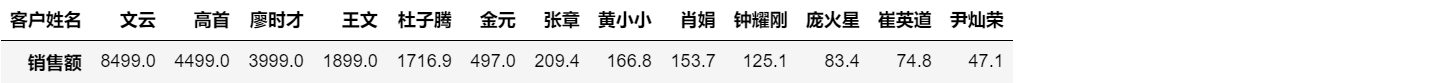

按照“类型名称”统计不同类型产品的销售总金额，并按照降序排列。如下图所示：
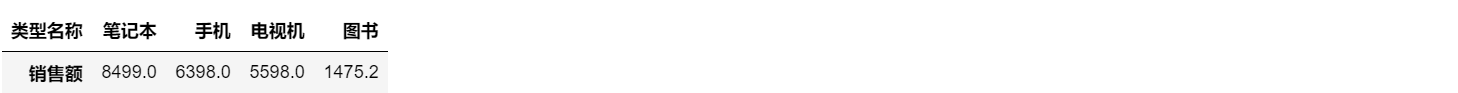

In [46]:
# 读取数据源中订单表数据，将四张表分别命名为df_1 df_2 df_3 df_4
df_1= pd.read_excel(r'数据源\订单表.xlsx',sheet_name= 0)
df_2= pd.read_excel(r'数据源\订单表.xlsx',sheet_name= 1)
df_3= pd.read_excel(r'数据源\订单表.xlsx',sheet_name= 2)
df_4= pd.read_excel(r'数据源\订单表.xlsx',sheet_name= 3)

In [47]:
# 观察表数据，上下合并表df_2和df_3，重置索引，并取出合并后的商品编号、商品类型、价格三列数据，将新数据命名为df1
df1 = pd.concat([df_2,df_3],ignore_index= True )[['商品编号','商品类型','价格']]
df1

,商品编号,商品类型,价格
0,100009177424,t020101,4499.0
1,100004559325,t020101,1899.0
2,100006232551,t020101,2999.0
3,100011351676,t020101,4999.0
4,100005724680,t030101,6099.0
5,100003688077,t030101,8499.0
6,100005603836,t030101,6299.0
7,100005638619,t030101,3599.0
8,100004541926,t0101,4199.0
9,100000615806,t0101,2699.0


In [48]:
# 观察表数据,将df1和df_1通过商品类型和类型编号进行左连接,将合并后数据命名为df2
df2 = pd.merge(df1,df_1,left_on= '商品类型',right_on= '类型编号',how= 'left')
df2

,商品编号,商品类型,价格,父类编号,类型编号,类型名称
0,100009177424,t020101,4499.0,t0201,t020101,手机
1,100004559325,t020101,1899.0,t0201,t020101,手机
2,100006232551,t020101,2999.0,t0201,t020101,手机
3,100011351676,t020101,4999.0,t0201,t020101,手机
4,100005724680,t030101,6099.0,t0301,t030101,笔记本
5,100003688077,t030101,8499.0,t0301,t030101,笔记本
6,100005603836,t030101,6299.0,t0301,t030101,笔记本
7,100005638619,t030101,3599.0,t0301,t030101,笔记本
8,100004541926,t0101,4199.0,t01,t0101,电视机
9,100000615806,t0101,2699.0,t01,t0101,电视机


In [51]:
# 观察表数据，将df_4和df2通过商品编号进行左连接，并且取出客户姓名、购买数量、价格、类型名称4列数据，命名为df_all
df_all = pd.merge(df_4,df2,on= "商品编号",how= "left")[["客户姓名","购买数量","价格","类型名称"]]
df_all

,客户姓名,购买数量,价格,类型名称
0,尹灿荣,1,47.1,图书
1,金元,2,79.0,图书
2,金元,1,59.8,图书
3,金元,4,69.8,图书
4,肖娟,1,48.8,图书
5,肖娟,1,39.6,图书
6,肖娟,1,29.8,图书
7,肖娟,1,35.5,图书
8,钟耀刚,3,41.7,图书
9,崔英道,1,35.5,图书


In [52]:
# 新增一列数据，名为销售额，销售额的值为购买数量*价格
df_all['销售额'] = df_all['购买数量']* df_all['价格']
df_all

,客户姓名,购买数量,价格,类型名称,销售额
0,尹灿荣,1,47.1,图书,47.1
1,金元,2,79.0,图书,158.0
2,金元,1,59.8,图书,59.8
3,金元,4,69.8,图书,279.2
4,肖娟,1,48.8,图书,48.8
5,肖娟,1,39.6,图书,39.6
6,肖娟,1,29.8,图书,29.8
7,肖娟,1,35.5,图书,35.5
8,钟耀刚,3,41.7,图书,125.1
9,崔英道,1,35.5,图书,35.5


In [53]:
# (1)分组聚合,对df_all按照客户姓名进行分组，对每个组的'销售额'进行求和，结果命名为df
df = df_all.groupby('客户姓名')['销售额'].sum()
df

客户姓名
尹灿荣      47.1
崔英道      74.8
庞火星      83.4
廖时才    3999.0
张章      209.4
文云     8499.0
杜子腾    1716.9
王文     1899.0
肖娟      153.7
金元      497.0
钟耀刚     125.1
高首     4499.0
黄小小     166.8
Name: 销售额, dtype: float64

In [55]:
# (2)对df按照销售额进行降序排列
df. sort_values(ascending= False,inplace= True )
df

客户姓名
文云     8499.0
高首     4499.0
廖时才    3999.0
王文     1899.0
杜子腾    1716.9
金元      497.0
张章      209.4
黄小小     166.8
肖娟      153.7
钟耀刚     125.1
庞火星      83.4
崔英道      74.8
尹灿荣      47.1
Name: 销售额, dtype: float64

In [56]:
# (3)将df转化为DataFrame的数据类型并转置
df = df.to_frame().T
df

客户姓名,文云,高首,廖时才,王文,杜子腾,金元,张章,黄小小,肖娟,钟耀刚,庞火星,崔英道,尹灿荣
销售额,8499.0,4499.0,3999.0,1899.0,1716.9,497.0,209.4,166.8,153.7,125.1,83.4,74.8,47.1


In [57]:
# 可视化
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'SimHei'    # 设置中文显示
plt.rcParams['axes.unicode_minus']=False  # 该语句解决图像中的“-”负号的乱码问题
%matplotlib inline

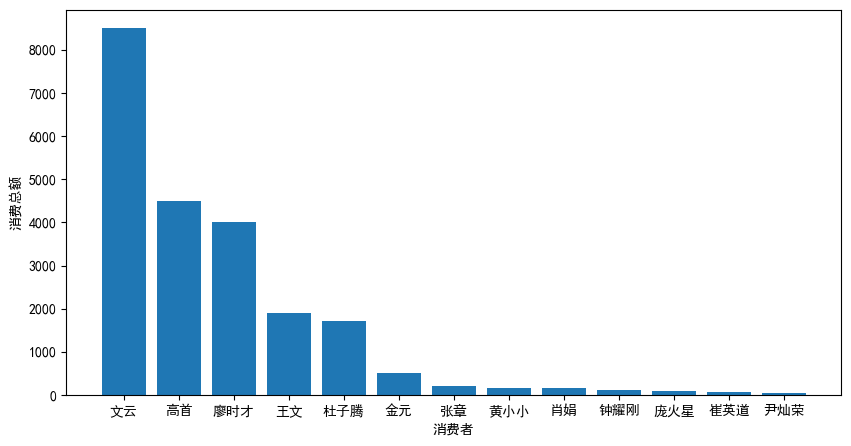

In [58]:
# 绘制消费者，消息总额竖直条形图，画布尺寸（10,5），x轴标签消费者，y轴标签消费总额
plt.figure(figsize= (10,5))
plt.bar(x= df.columns,height= df.loc['销售额'])
plt.xlabel('消费者')
plt.ylabel('消费总额')
plt.show()

In [60]:
# 对df_all按照类型名称进行分组，对每个组的'销售额'进行求和，对销售额进行降序排列，转化为DataFrame的数据类型并转置
df_all.groupby('类型名称')['销售额'].sum().sort_values(ascending= False).to_frame().T

类型名称,笔记本,手机,电视机,图书
销售额,8499.0,6398.0,5598.0,1475.2


# 6. 总结

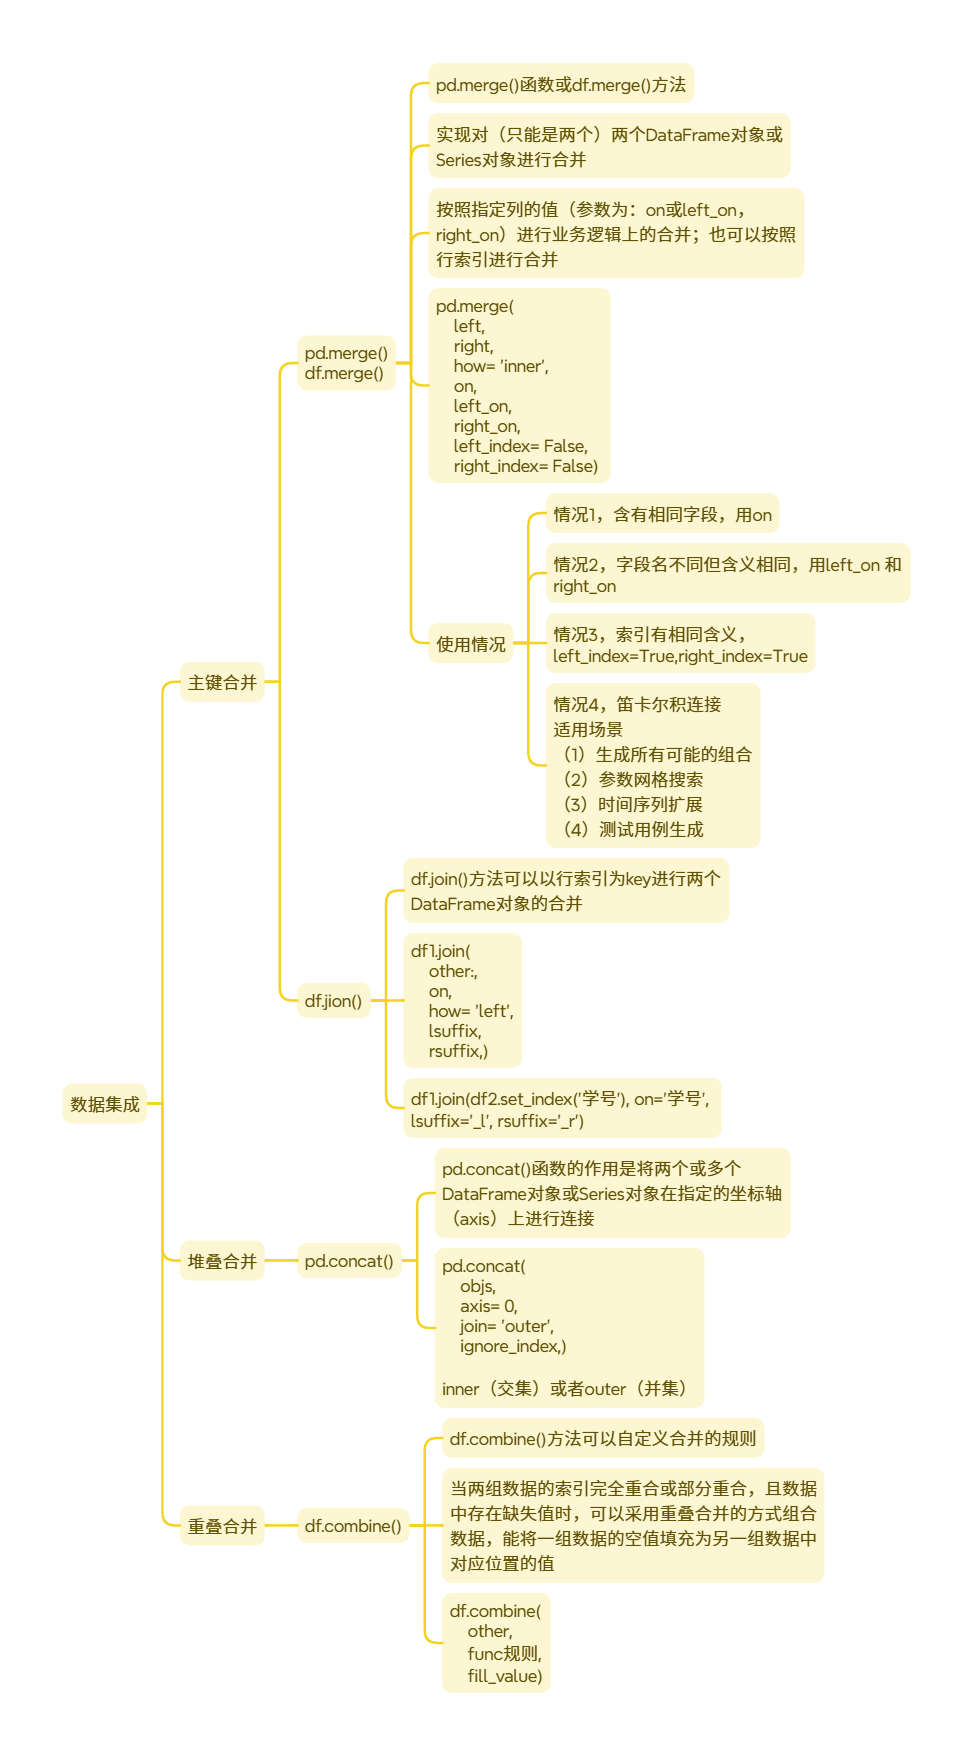